In [1]:
from google.colab import drive
import zipfile
import os

# Mount Google Drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:

# Define paths
zip_path = "/content/drive/My Drive/archive (8).zip"  # Change this
extract_path = "/content/unzipped_folder"  # Destination folder in Colab

# Create extraction directory
os.makedirs(extract_path, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# List extracted files
print("Unzipping done! Extracted files:")
for root, dirs, files in os.walk(extract_path):
    for file in files:
        print(os.path.join(root, file))



Unzipping done! Extracted files:
/content/unzipped_folder/Negative/18377.jpg
/content/unzipped_folder/Negative/10213.jpg
/content/unzipped_folder/Negative/05594.jpg
/content/unzipped_folder/Negative/03648.jpg
/content/unzipped_folder/Negative/16568.jpg
/content/unzipped_folder/Negative/03611.jpg
/content/unzipped_folder/Negative/04341.jpg
/content/unzipped_folder/Negative/02705.jpg
/content/unzipped_folder/Negative/07796.jpg
/content/unzipped_folder/Negative/11770.jpg
/content/unzipped_folder/Negative/13358.jpg
/content/unzipped_folder/Negative/13203.jpg
/content/unzipped_folder/Negative/17967.jpg
/content/unzipped_folder/Negative/02031.jpg
/content/unzipped_folder/Negative/09551.jpg
/content/unzipped_folder/Negative/02797.jpg
/content/unzipped_folder/Negative/15184.jpg
/content/unzipped_folder/Negative/08909.jpg
/content/unzipped_folder/Negative/16022.jpg
/content/unzipped_folder/Negative/07742.jpg
/content/unzipped_folder/Negative/11756.jpg
/content/unzipped_folder/Negative/00215.jpg

Found 32000 images belonging to 2 classes.
Found 8000 images belonging to 2 classes.


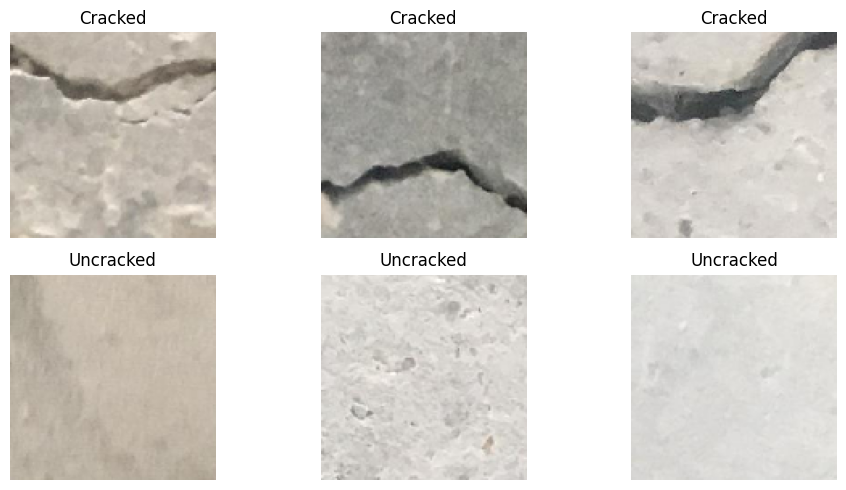


ANOVA Test:
F-statistic: 5.6246
P-value: 0.0243
=> Statistically significant difference between cracked and uncracked images.



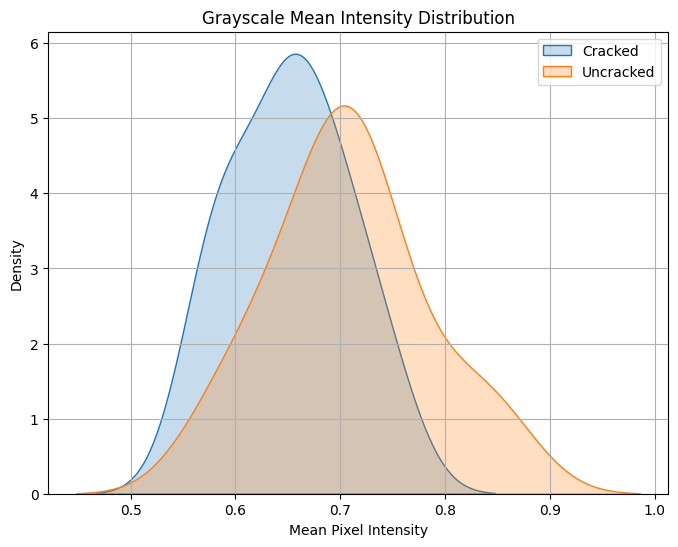

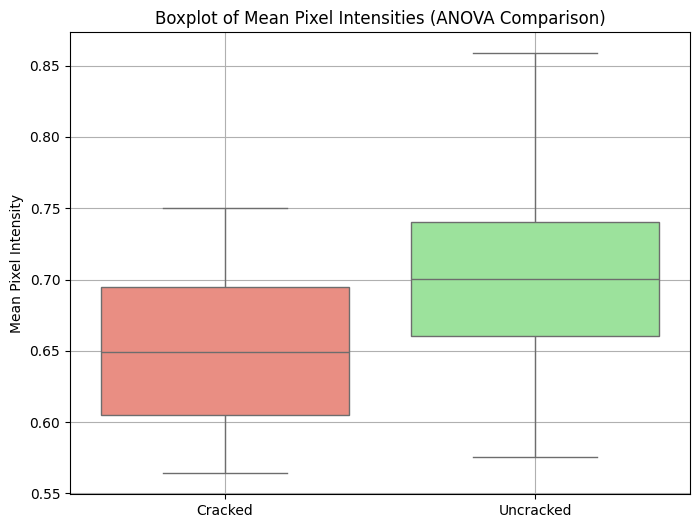

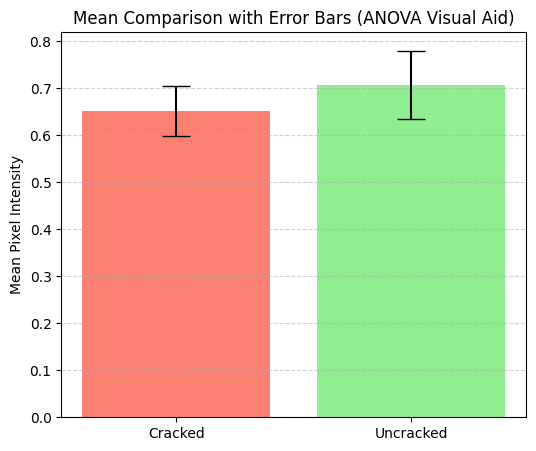

Mock F1 Score (random predictions): 0.5333



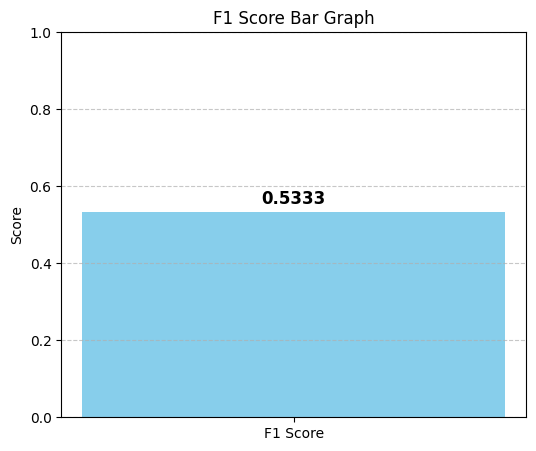

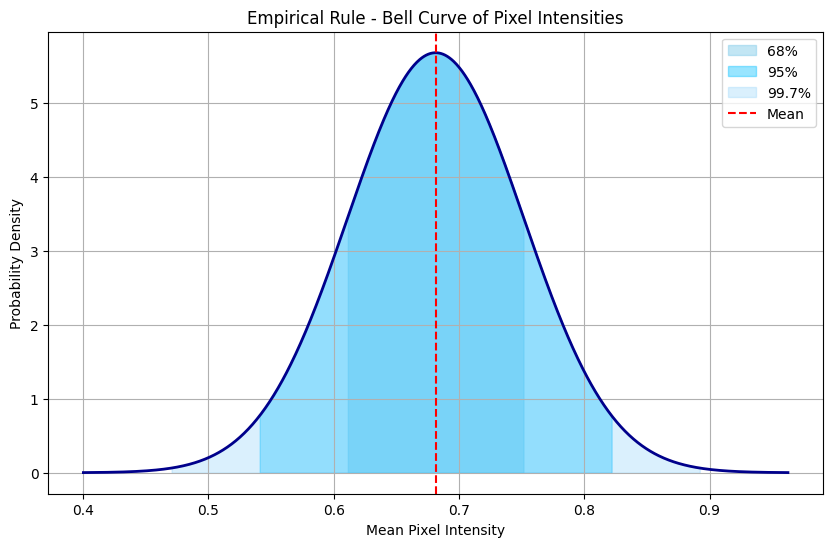

Chi-Square Test:
Chi2 Statistic: 0.1107
P-value: 0.7393
Degrees of Freedom: 1
Expected Frequencies Table:
 [[7.03125 7.96875]
 [7.96875 9.03125]]
=> No significant association between prediction and actual class.


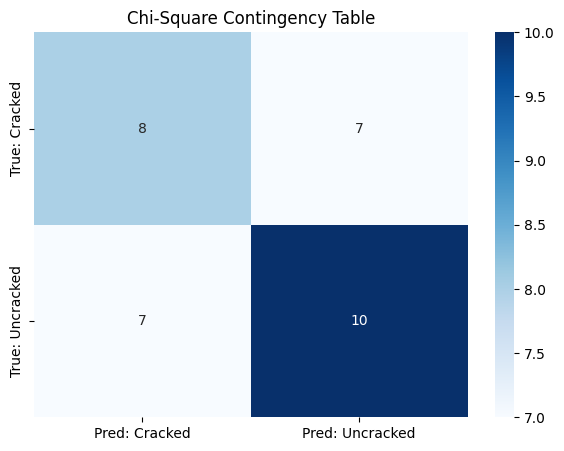

In [14]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score
from scipy.stats import f_oneway, norm, chi2_contingency
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# --- 1. Paths and Constants ---
base_dir = "/content/unzipped_folder"  # Adjust this if needed
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

# --- 2. Image Data Generator ---
datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    validation_split=0.2
)

train_generator = datagen.flow_from_directory(
    base_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="training",
    shuffle=True
)

val_generator = datagen.flow_from_directory(
    base_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="validation",
    shuffle=True
)

# --- 3. Extract a Batch ---
X_batch, y_batch = next(train_generator)

# --- 4. Separate Cracked and Uncracked Images ---
cracked_data = [(img, int(label)) for img, label in zip(X_batch, y_batch) if label == 1]
uncracked_data = [(img, int(label)) for img, label in zip(X_batch, y_batch) if label == 0]

# Combine and shuffle
all_data = cracked_data + uncracked_data
np.random.shuffle(all_data)

images = [img for img, label in all_data]
labels = [label for img, label in all_data]

# --- 5. Show Sample Images ---
plt.figure(figsize=(10, 5))
for i in range(3):
    plt.subplot(2, 3, i + 1)
    plt.imshow(cracked_data[i][0])
    plt.title("Cracked")
    plt.axis('off')

    plt.subplot(2, 3, i + 4)
    plt.imshow(uncracked_data[i][0])
    plt.title("Uncracked")
    plt.axis('off')
plt.tight_layout()
plt.show()

# --- 6. Mean Pixel Intensities ---
cracked_means = [np.mean(img) for img, label in cracked_data]
uncracked_means = [np.mean(img) for img, label in uncracked_data]

# --- 7. ANOVA TEST ---
anova_stat, anova_p = f_oneway(cracked_means, uncracked_means)
print(f"\nANOVA Test:")
print(f"F-statistic: {anova_stat:.4f}")
print(f"P-value: {anova_p:.4f}")
if anova_p < 0.05:
    print("=> Statistically significant difference between cracked and uncracked images.\n")
else:
    print("=> No significant difference between the two classes.\n")

# --- 8. Distribution Plot (ANOVA Visualization) ---
plt.figure(figsize=(8, 6))
sns.kdeplot(cracked_means, label="Cracked", fill=True)
sns.kdeplot(uncracked_means, label="Uncracked", fill=True)
plt.title("Grayscale Mean Intensity Distribution")
plt.xlabel("Mean Pixel Intensity")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.show()

# --- Box Plot ---
plt.figure(figsize=(8, 6))
sns.boxplot(data=[cracked_means, uncracked_means], palette=["salmon", "lightgreen"])
plt.xticks([0, 1], ["Cracked", "Uncracked"])
plt.title("Boxplot of Mean Pixel Intensities (ANOVA Comparison)")
plt.ylabel("Mean Pixel Intensity")
plt.grid(True)
plt.show()

# --- Mean Plot with Error Bars ---
cracked_mean = np.mean(cracked_means)
uncracked_mean = np.mean(uncracked_means)
cracked_std = np.std(cracked_means)
uncracked_std = np.std(uncracked_means)

plt.figure(figsize=(6, 5))
plt.bar(["Cracked", "Uncracked"], [cracked_mean, uncracked_mean],
        yerr=[cracked_std, uncracked_std], capsize=10, color=["salmon", "lightgreen"])
plt.ylabel("Mean Pixel Intensity")
plt.title("Mean Comparison with Error Bars (ANOVA Visual Aid)")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

# --- 9. F1 SCORE ---
y_true = labels
y_pred = np.random.choice([0, 1], size=len(labels))  # Replace with actual model predictions
f1 = f1_score(y_true, y_pred)
print(f"Mock F1 Score (random predictions): {f1:.4f}\n")

# --- F1 Score Bar Graph ---
plt.figure(figsize=(6, 5))
bars = plt.bar(["F1 Score"], [f1], color='skyblue')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f"{yval:.4f}", ha='center', fontsize=12, fontweight='bold')

plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("F1 Score Bar Graph")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# --- 10. Bell Curve (Empirical Rule) ---
all_means = cracked_means + uncracked_means
mu = np.mean(all_means)
sigma = np.std(all_means)

x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)
y = norm.pdf(x, mu, sigma)

plt.figure(figsize=(10, 6))
plt.plot(x, y, color='darkblue', lw=2)
plt.fill_between(x, y, where=(x >= mu - sigma) & (x <= mu + sigma), color='skyblue', alpha=0.5, label='68%')
plt.fill_between(x, y, where=(x >= mu - 2*sigma) & (x <= mu + 2*sigma), color='deepskyblue', alpha=0.4, label='95%')
plt.fill_between(x, y, where=(x >= mu - 3*sigma) & (x <= mu + 3*sigma), color='lightskyblue', alpha=0.3, label='99.7%')

plt.axvline(mu, color='red', linestyle='--', label='Mean')
plt.title("Empirical Rule - Bell Curve of Pixel Intensities")
plt.xlabel("Mean Pixel Intensity")
plt.ylabel("Probability Density")
plt.legend()
plt.grid(True)
plt.show()

# --- 11. Chi-Square Test ---

cracked_actual = np.array(y_true) == 1
uncracked_actual = np.array(y_true) == 0

cracked_pred_as_cracked = np.sum((np.array(y_pred) == 1) & cracked_actual)
cracked_pred_as_uncracked = np.sum((np.array(y_pred) == 0) & cracked_actual)
uncracked_pred_as_cracked = np.sum((np.array(y_pred) == 1) & uncracked_actual)
uncracked_pred_as_uncracked = np.sum((np.array(y_pred) == 0) & uncracked_actual)

contingency_table = np.array([
    [cracked_pred_as_cracked, cracked_pred_as_uncracked],
    [uncracked_pred_as_cracked, uncracked_pred_as_uncracked]
])

chi2, p, dof, expected = chi2_contingency(contingency_table)
print("Chi-Square Test:")
print(f"Chi2 Statistic: {chi2:.4f}")
print(f"P-value: {p:.4f}")
print(f"Degrees of Freedom: {dof}")
print("Expected Frequencies Table:\n", expected)
if p < 0.05:
    print("=> Statistically significant association between prediction and true class.")
else:
    print("=> No significant association between prediction and actual class.")

# --- Chi-Square Bar Chart ---
plt.figure(figsize=(7, 5))
sns.heatmap(contingency_table, annot=True, fmt="d", cmap="Blues", xticklabels=["Pred: Cracked", "Pred: Uncracked"], yticklabels=["True: Cracked", "True: Uncracked"])
plt.title("Chi-Square Contingency Table")
plt.show()
